# 12. Finding Candidates in Ten Million

**The question.** Before any pair is scored, blocking decides which pairs *exist*. At
1e7–1e9 records the candidate budget — how many comparisons per record you can afford —
is the binding constraint, and the field offers three ways to spend it: multi-pass
deterministic **matchkeys** (Census BigMatch ~10 passes, ONS 29 matchkeys — the settled
large-scale practice), sparse lexical **BM25** top-k (Sparkly's Lucene-backed baseline
that beat eight learned blockers), and dense **ANN** top-k over learned whole-record
embeddings. BAS-02 asks the head-to-head the literature has not settled for person
records: **at a matched per-record candidate budget, does dense retrieval actually find
more of the true pairs — and at what measured cost?**

**Why the card cannot presume dense wins.** The lit review marks dense-beats-sparse as
CONTESTED: Sparkly's top-k TF/IDF beat 8 state-of-the-art learned blockers
(recall 86.6–99.96%), convergent with ShallowBlocker (2024) and Zeakis et al. (VLDB
2023)'s mixed results and vectorization overheads; Reimers & Gurevych (2021) measured
dense retrieval degrading with index size *faster* than sparse; and the canonical deep-ER
evidence base contains essentially no person records. So the pre-registered prediction
below is sparse-favored at small budgets, and the notebook measures where — if anywhere —
dense earns its place (the heavily-corrupted matches where token overlap and phonetic
keys break).

**What this notebook settles.** (1) One encoder trained with the **TRN-01 winning
recipe** read from `trn01_loss_matrix` (recipe and budget stated, not assumed), encoding
the full calibrated corpus. (2) The **frontier at matched budget** k ∈ {1, 2, 5, 10, 25}:
matchkeys vs BM25 vs ANN-flat vs ANN-HNSW, each scored by pair-completeness on the
entity-disjoint eval half (entity-bootstrap CIs, paired resamples), reduction ratio,
realized candidates/record, and measured wall-clock/record — dense encode time amortized
*and counted* in a total-cost column. (3) The **noise-regime slice**: per-method PC at
k=10 on heavily- vs lightly-corrupted true pairs, with the generator ops-count
instrument cross-checked live. (4) The `# [RUN-IN-TARGET node]` placard prices the 1e7
matched-compute frontier from THIS run's measured coefficients.

**Scope honesty, up front.** At smoke tier the "ten million" is a ~32k-record calibrated
corpus standing in for the target-tier corpus — same code path, tier only via config.
The dense arms depend on ONE trained encoder (one seed, one corpus draw): every verdict
below says "demonstration", and the MET-04 replicate bar is quoted as the caution. No
entity appears on both sides of the train/eval boundary (`met07_splits`, PLAN §5); the
corpus is `historical_50k`-derived (public records), NC data enters only as aggregate
channel rates — nothing here needs display masking.

In [1]:
import time

import numpy as np
import pandas as pd
from IPython.display import display

from er_lab.blocking import ann, matchkeys, sparse
from er_lab.config import config_hash, load_config_from_env, set_all_seeds
from er_lab.data.schema import NON_TEXT_ROLES, ROLES
from er_lab.eval.metrics import blocking_metrics
from er_lab.infra.artifacts import ArtifactRegistry
from er_lab.infra.device import describe_platform
from er_lab.models.encoders import build_encoder
from er_lab.reporting import figures
from er_lab.reporting.cards import conjecture_card, verdict_box
from er_lab.serialize import serialize_frame
from er_lab.train.loop import train_encoder

cfg = load_config_from_env()
registry = ArtifactRegistry.from_env()
figures.setup_style()
set_all_seeds(cfg.run.seed)
NB_T0 = time.time()
SECTION_TIMES: list[tuple[str, float]] = []


def tick(label: str, t0: float) -> None:
    """Record and print one section's wall-clock — the smoke budget is measured, not vibes."""
    secs = time.time() - t0
    SECTION_TIMES.append((label, secs))
    print(f"[section timing] {label}: {secs:.0f}s")

In [2]:
# Tier banner — where and under what config this run happened.
print(f"tier        = {cfg.run.tier}")
print(f"config hash = {config_hash(cfg)}")
for key, val in describe_platform().items():
    print(f"  {key:>14}: {val}")

tier        = smoke
config hash = 129c9d9243ca
              os: Linux-6.18.44-fc-v21-x86_64-with-glibc2.39
          python: 3.11.15
           torch: 2.13.0+cu130
  cuda_available: False
   mps_available: False
       cpu_count: 4
          ram_gb: 15.7


## Tier constants — and what "matched budget" means here

**The budget unit is candidates per record.** For BM25 and ANN, k is the number of
top-k neighbors each record proposes; for matchkeys it is the per-record candidate cap
(`budget_k`) applied over the OR-union of passes — the module's documented budget
semantics differ slightly (a proposal cap vs a participation cap), so the frontier table
carries **realized candidates/record** and total pairs, and the cost figure plots
measured cost, not nominal k. The k grid {1, 2, 5, 10, 25} is protocol (identical at
every tier); sizes below scale with tier. Encoder shape and step budget are the same
tier table as notebook 09, so the TRN-01 recipe transfers verbatim. Smoke budget for the
whole notebook: **<= ~30 min on the 4-CPU container** (measured per section, printed at
the end; the BM25 arm re-tokenizes and re-indexes per call, which is honest but slow).

In [3]:
TIER = str(cfg.run.tier)
K_GRID = (1, 2, 5, 10, 25)  # matched per-record candidate budgets (protocol, all tiers)
SLICE_K = 10  # the budget at which the noise-regime slice is read
HEAVY_MIN_DIFF = 3  # noise dial: a pair is 'heavy' when >= 3 serialized roles disagree
STEPS_BY_TIER = {"smoke": 250, "mid": 2000, "target": 4000, "analytical": 250}
TRAIN_N = {"smoke": 3_000, "mid": None, "target": None, "analytical": 3_000}  # train records
N_BOOT = {"smoke": 400, "mid": 1000, "target": 2000, "analytical": 400}[TIER]
MODEL_SHAPE = {
    "smoke": {"dim": 128, "layers": 2, "heads": 4, "max_len": 128},
    "mid": {"dim": 256, "layers": 4, "heads": 4, "max_len": 192},
    "target": {"dim": 384, "layers": 6, "heads": 6, "max_len": 192},
    "analytical": {"dim": 128, "layers": 2, "heads": 4, "max_len": 128},
}[TIER]
STEPS = STEPS_BY_TIER[TIER]
ENC_BATCH = 256  # inference encode batch
PRIMARY_SEED = int(cfg.run.seed)

# Encoder + budget through the typed cfg keys, so every registered artifact's config hash
# records exactly what trained (model.kind may flip to 'pretrained' if the TRN-01 winner
# is that regime AND weights are loadable here — the §3 gate).
cfg.model.kind = "scratch_char"
cfg.model.dim = MODEL_SHAPE["dim"]
cfg.model.layers = MODEL_SHAPE["layers"]
cfg.model.heads = MODEL_SHAPE["heads"]
cfg.model.max_len = MODEL_SHAPE["max_len"]
cfg.train.steps = STEPS
BATCH = int(cfg.train.batch_size)
print(f"tier={TIER}: k grid {K_GRID}, slice k={SLICE_K}, heavy >= {HEAVY_MIN_DIFF} roles differ; "
      f"encoder shape {MODEL_SHAPE}, steps={STEPS}, batch={BATCH}, "
      f"train-slice budget {TRAIN_N[TIER]}, n_boot={N_BOOT}")

tier=smoke: k grid (1, 2, 5, 10, 25), slice k=10, heavy >= 3 roles differ; encoder shape {'dim': 128, 'layers': 2, 'heads': 4, 'max_len': 128}, steps=250, batch=64, train-slice budget 3000, n_boot=400


## 1. The arena: one corpus to block, one eval half to score on

The **whole calibrated corpus is the blocking arena** — candidate generation has no
train/eval split in production, and index size is part of what is being measured
(Reimers & Gurevych's dense-degrades-with-scale result is exactly about this). But
**pair-completeness is scored only on the entity-disjoint eval half**: the dense encoder
trains on the train half, so counting its performance on entities it saw would be the
leakage optimism MET-07 measured. All four methods are scored on the same eval-half true
pairs (matched, paired bootstrap), and a seen-vs-unseen check below §4 measures the gap
the discipline exists to prevent. Every method's budget is partly spent on cross-half
neighbors — equally for all methods, so the comparison stands.

`TEXT_ROLES` inherits notebook 08's **measured decision**: `full_name` is EXCLUDED — it
is a verbatim join of the name parts that roughly doubles serialized length (forcing
truncation at the smoke byte window) and notebook 05 leaves it stale under nickname/typo
edits, so keeping it would leak the clean name past the injected noise. BM25 and the
encoder see the *same serialized text*; matchkeys reads the raw fields (that asymmetry
is the method, not a bug).

In [4]:
t_sec = time.time()
corpus, corpus_meta = registry.load("calibrated_corpus", tier=cfg.run.tier)
ops_log, _ops_meta = registry.load("calibrated_corpus_ops", tier=cfg.run.tier)
splits, _splits_meta = registry.load("met07_splits", tier=cfg.run.tier)
CORPUS_PROVENANCE = (
    f"calibrated_corpus run {corpus_meta['created_at']} (cfg {corpus_meta['config_hash']}, "
    f"tier {corpus_meta['tier']}, seed {corpus_meta['extra']['seed']})"
)
print(f"corpus: {CORPUS_PROVENANCE}")
print(f"  {len(corpus):,} records / {corpus['entity_id'].nunique():,} entities; "
      f"source={corpus['source'].unique().tolist()} (public historical records; NC enters this "
      "notebook only as the aggregate channel rates in the corpus meta — nothing to mask)")

# NB08's measured field-set decision, inherited (see the section note above).
TEXT_ROLES = ["given_name", "family_name", "dob", "city", "zip", "sex"]
KEEP_COLS = ["record_id", "entity_id"] + TEXT_ROLES
assert all(r in corpus.columns for r in TEXT_ROLES), "corpus is missing a declared text role"
_loop_roles = [c for c in KEEP_COLS if c in ROLES and c not in NON_TEXT_ROLES]
assert _loop_roles == TEXT_ROLES, (
    "training-loop role rule would diverge from TEXT_ROLES on the KEEP_COLS frame: "
    f"{_loop_roles}"
)
print(f"TEXT_ROLES (full_name excluded, NB08 decision) = {TEXT_ROLES}")

SCHEME = "entity_disjoint"
train_ids = set(splits["schemes"][SCHEME]["train"])
eval_ids = set(splits["schemes"][SCHEME]["eval"])
straddle = splits["metadata"]["checks"][SCHEME]["entities_straddling"]
assert straddle == 0, "entity-disjoint split must have zero straddling entities (PLAN §5)"
arena = corpus.reset_index(drop=True)  # the WHOLE corpus gets blocked
N_ARENA = len(arena)
train_full = corpus[corpus["record_id"].isin(train_ids)].reset_index(drop=True)
eval_full = corpus[corpus["record_id"].isin(eval_ids)].reset_index(drop=True)
TRUTH_ALL = arena.set_index(arena["record_id"].astype(str))["entity_id"]
print(f"arena: {N_ARENA:,} records (all blocked); split {SCHEME}: "
      f"{len(train_full):,} train / {len(eval_full):,} eval records "
      f"({eval_full['entity_id'].nunique():,} eval entities, 0 straddling)")

SER_SCHEME, SER_MISSING = str(cfg.serialize.scheme), str(cfg.serialize.missing)
ARENA_TEXTS = serialize_frame(
    arena, text_roles=TEXT_ROLES, scheme=SER_SCHEME, missing=SER_MISSING
).tolist()
_blens = np.array([len(t.encode("utf-8")) for t in ARENA_TEXTS])
print(f"serialization: scheme={SER_SCHEME} missing={SER_MISSING}; median {int(np.median(_blens))} "
      f"bytes, {(_blens > cfg.model.max_len - 1).mean():.0%} exceed the encoder's "
      f"max_len={cfg.model.max_len} byte window (truncated for the dense arm; BM25 sees the "
      "full string — a real, stated asymmetry of the smoke window)")

corpus: calibrated_corpus run 2026-08-26T02:41:13.372218+00:00 (cfg 129c9d9243ca, tier smoke, seed 17)
  32,259 records / 2,507 entities; source=['historical_50k'] (public historical records; NC enters this notebook only as the aggregate channel rates in the corpus meta — nothing to mask)
TEXT_ROLES (full_name excluded, NB08 decision) = ['given_name', 'family_name', 'dob', 'city', 'zip', 'sex']
arena: 32,259 records (all blocked); split entity_disjoint: 16,164 train / 16,095 eval records (1,255 eval entities, 0 straddling)


serialization: scheme=colval missing=token; median 162 bytes, 100% exceed the encoder's max_len=128 byte window (truncated for the dense arm; BM25 sees the full string — a real, stated asymmetry of the smoke window)


### The scoring instruments: eval-half true pairs, entity-bootstrap CIs

Pair-completeness has a natural resampling unit — the **entity** (MET-03's coverage
lesson: pairs within an entity are maximally dependent). `er_lab.eval.bootstrap` targets
clusterings, not candidate sets (package gap, noted), so a notebook-local percentile
bootstrap resamples eval entities with replacement and recomputes PC as the ratio of
found-pair to true-pair mass; **one shared resample matrix across every method, k and
slice** makes all deltas paired.

In [5]:
def true_pair_table(frame: pd.DataFrame) -> pd.DataFrame:
    """All unordered same-entity pairs of *frame* as DataFrame[a, b, entity, key], a<b."""
    rows: list[tuple[str, str, str]] = []
    for ent, grp in frame.groupby("entity_id", sort=True):
        ids = sorted(grp["record_id"].astype(str))
        for i in range(len(ids) - 1):
            for j in range(i + 1, len(ids)):
                rows.append((ids[i], ids[j], str(ent)))
    out = pd.DataFrame(rows, columns=["a", "b", "entity"])
    out["key"] = out["a"] + "||" + out["b"]
    return out


EV_PAIRS = true_pair_table(eval_full)
ENT_CODES, ENT_LABELS = pd.factorize(EV_PAIRS["entity"])
N_ENT = len(ENT_LABELS)
T_E = np.bincount(ENT_CODES, minlength=N_ENT).astype(float)
_rng_boot = np.random.default_rng(PRIMARY_SEED + 41)
BOOT_IDX = _rng_boot.integers(0, N_ENT, size=(N_BOOT, N_ENT))
print(f"eval truth: {len(EV_PAIRS):,} true pairs over {N_ENT:,} multi-record eval entities; "
      f"{N_BOOT} shared entity resamples (paired across methods/k/slices)")


def pc_ci(found: np.ndarray, subset: np.ndarray | None = None) -> tuple[float, float, float]:
    """(point, lo, hi): pair-completeness with a percentile entity-bootstrap 95% CI."""
    m = np.ones(len(found), dtype=bool) if subset is None else subset
    f_e = np.bincount(ENT_CODES[m], weights=found[m].astype(float), minlength=N_ENT)
    t_e = np.bincount(ENT_CODES[m], minlength=N_ENT).astype(float)
    with np.errstate(invalid="ignore"):
        reps = f_e[BOOT_IDX].sum(axis=1) / t_e[BOOT_IDX].sum(axis=1)
    return (
        float(found[m].mean()),
        float(np.nanpercentile(reps, 2.5)),
        float(np.nanpercentile(reps, 97.5)),
    )


def paired_delta_ci(
    found_x: np.ndarray, found_y: np.ndarray, subset: np.ndarray | None = None
) -> tuple[float, float, float]:
    """(point, lo, hi) for PC(x) − PC(y) on SHARED entity resamples — a paired delta."""
    m = np.ones(len(found_x), dtype=bool) if subset is None else subset
    fx = np.bincount(ENT_CODES[m], weights=found_x[m].astype(float), minlength=N_ENT)
    fy = np.bincount(ENT_CODES[m], weights=found_y[m].astype(float), minlength=N_ENT)
    t_e = np.bincount(ENT_CODES[m], minlength=N_ENT).astype(float)
    with np.errstate(invalid="ignore"):
        reps = (fx[BOOT_IDX].sum(axis=1) - fy[BOOT_IDX].sum(axis=1)) / t_e[BOOT_IDX].sum(axis=1)
    point = float(found_x[m].mean() - found_y[m].mean())
    return point, float(np.nanpercentile(reps, 2.5)), float(np.nanpercentile(reps, 97.5))


tick("§1 arena + instruments", t_sec)

eval truth: 187,785 true pairs over 991 multi-record eval entities; 400 shared entity resamples (paired across methods/k/slices)
[section timing] §1 arena + instruments: 1s


## 2. The conjecture, before any index is built

The card is registered now — before the encoder trains, before a single candidate pair
exists — and it deliberately sides with the *contested* literature reading (sparse-first)
rather than the lab's own working hypothesis. The decision rule lives inside the
prediction; the verdict at the end scores exactly it.

In [6]:
_ = conjecture_card(
    card_id="BAS-02",
    conjecture=(
        "On noisy person records at a matched per-record candidate budget, dense ANN "
        "retrieval over trained whole-record embeddings does not beat well-tuned sparse "
        "BM25 blocking at small budgets — the lit review marks dense-beats-sparse as "
        "CONTESTED (Sparkly / ShallowBlocker / Zeakis et al.), and this card pre-registers "
        "the sparse-favored reading — with dense closing as the budget grows and earning "
        "whatever place it has on heavily-corrupted matches where token overlap and "
        "phonetic keys break."
    ),
    pressure=(
        "blocking method {multi-pass deterministic matchkeys (OR-union passes, per-record "
        "budget cap), BM25 top-k over the serialized records, dense ANN top-k over trained "
        "whole-record embeddings (exact flat index and HNSW)} at matched per-record budget "
        "k in {1, 2, 5, 10, 25} over the full calibrated corpus; the dense encoder is "
        "trained ONCE with the TRN-01 winning recipe read from trn01_loss_matrix (matched "
        "optimizer-step budget, in-batch negatives, no augmentation, TRN-01's field-set "
        "and serialization locks) on the entity-disjoint train half"
    ),
    property=(
        "candidate-set pair-completeness (the share of true same-entity pairs that survive "
        "blocking) on the entity-disjoint eval half, overall and sliced by measured pair "
        "corruption — the number of the six serialized roles on which the two members "
        "disagree, with the generator ops-count instrument cross-checked in-notebook"
    ),
    metric=(
        "pair-completeness at each matched k with entity-resampled percentile-bootstrap "
        "95% CIs, paired across methods on shared resamples; plus reduction ratio, "
        "realized candidates per record, and measured wall-clock per record with dense "
        "encode time amortized and counted in a total-cost column"
    ),
    prediction=(
        "P1: BM25 pair-completeness >= dense-flat at every k in {1, 2, 5, 10} (point "
        "estimates, eval half). P2: dense-flat closes to within 0.05 absolute PC of BM25 "
        "at k=25. P3 (subordinate): HNSW gives up <= 0.02 PC vs flat at k=10 — at this "
        "scale the index, not the embedding, is not the bottleneck. Decision rule, "
        "pre-registered: CONFIRMED iff P1 and P2 both hold; REFUTED iff dense-flat beats "
        "BM25 at some k <= 10 with the paired entity-bootstrap 95% CI on the delta "
        "excluding zero, or P2 fails with the k=25 delta CI entirely beyond the 0.05 "
        "margin; UNEXPLAINED otherwise. P3 and the corruption-slice reading (dense ahead, "
        "if anywhere, on pairs disagreeing on >= 3 roles) are scored as stated but cannot "
        "flip the outcome. One trained encoder, one corpus draw: whatever the outcome, "
        "the smoke row is a demonstration and the target-tier frontier is the "
        "adjudication."
    ),
    registry=registry,
)

### Conjecture card `BAS-02`

| | |
|---|---|
| **Conjecture** | On noisy person records at a matched per-record candidate budget, dense ANN retrieval over trained whole-record embeddings does not beat well-tuned sparse BM25 blocking at small budgets — the lit review marks dense-beats-sparse as CONTESTED (Sparkly / ShallowBlocker / Zeakis et al.), and this card pre-registers the sparse-favored reading — with dense closing as the budget grows and earning whatever place it has on heavily-corrupted matches where token overlap and phonetic keys break. |
| **Pressure (dial)** | blocking method {multi-pass deterministic matchkeys (OR-union passes, per-record budget cap), BM25 top-k over the serialized records, dense ANN top-k over trained whole-record embeddings (exact flat index and HNSW)} at matched per-record budget k in {1, 2, 5, 10, 25} over the full calibrated corpus; the dense encoder is trained ONCE with the TRN-01 winning recipe read from trn01_loss_matrix (matched optimizer-step budget, in-batch negatives, no augmentation, TRN-01's field-set and serialization locks) on the entity-disjoint train half |
| **Embedding property** | candidate-set pair-completeness (the share of true same-entity pairs that survive blocking) on the entity-disjoint eval half, overall and sliced by measured pair corruption — the number of the six serialized roles on which the two members disagree, with the generator ops-count instrument cross-checked in-notebook |
| **System metric** | pair-completeness at each matched k with entity-resampled percentile-bootstrap 95% CIs, paired across methods on shared resamples; plus reduction ratio, realized candidates per record, and measured wall-clock per record with dense encode time amortized and counted in a total-cost column |
| **Pre-registered prediction** | P1: BM25 pair-completeness >= dense-flat at every k in {1, 2, 5, 10} (point estimates, eval half). P2: dense-flat closes to within 0.05 absolute PC of BM25 at k=25. P3 (subordinate): HNSW gives up <= 0.02 PC vs flat at k=10 — at this scale the index, not the embedding, is not the bottleneck. Decision rule, pre-registered: CONFIRMED iff P1 and P2 both hold; REFUTED iff dense-flat beats BM25 at some k <= 10 with the paired entity-bootstrap 95% CI on the delta excluding zero, or P2 fails with the k=25 delta CI entirely beyond the 0.05 margin; UNEXPLAINED otherwise. P3 and the corruption-slice reading (dense ahead, if anywhere, on pairs disagreeing on >= 3 roles) are scored as stated but cannot flip the outcome. One trained encoder, one corpus draw: whatever the outcome, the smoke row is a demonstration and the target-tier frontier is the adjudication. |

*Immutable — sha256 `3df9f8259fe9`; registered before the affected runs, never edited (PLAN §5).*


## 3. One encoder, the TRN-01 winning recipe — read, not chosen

The recipe is **read from the registry**: the best-F1 row of `trn01_loss_matrix` among
the regimes runnable in this container (the pretrained regime needs weights the smoke
sandbox cannot fetch — same gate as notebook 09). TRN-01's own verdict read its ranking
through the MET-04 bar, so the "winner" is a single-seed point ranking and is inherited
here as the pre-registered *choice*, caveat carried. The MET-04 caution bars load with
it: the meta's `sd_replicate` excludes the residual component, so the residual-inclusive
bar this notebook quotes is computed from the registered variance components and said so.

In [7]:
t_sec = time.time()
trn01, trn01_meta = registry.load("trn01_loss_matrix", tier=cfg.run.tier)
met04, met04_meta = registry.load("met04_power_table", tier=cfg.run.tier)
SD_REPLICATE = float(met04_meta["extra"]["sd_replicate"])
_comps = met04[met04["kind"] == "variance_component"].set_index("component")["variance"]
if "detect_bar_residual_inclusive" in met04_meta["extra"]:
    BAR_FULL = float(met04_meta["extra"]["detect_bar_residual_inclusive"])
    _bar_src = "read from met04_power_table meta"
else:
    BAR_FULL = float(2.0 * np.sqrt(2.0) * np.sqrt(_comps.sum()))
    _bar_src = ("computed here as 2*sqrt(2)*sqrt(seed+noise_draw+residual) — the registered "
                "meta carries only the residual-EXCLUSIVE sd_replicate")
print(f"MET-04 bars (B3F1 units; table scope: {met04['scope'].iloc[0]}): "
      f"sd_replicate={SD_REPLICATE:.4f}, residual-inclusive single-seed bar={BAR_FULL:.4f} "
      f"({_bar_src}). PC is a different metric — the bar is quoted as the order-of-magnitude "
      "caution for anything downstream of ONE trained encoder, not as a PC threshold.")

PRETRAINED_READY = cfg.paths.hf_local is not None or TIER in ("mid", "target")
_runnable = ["scratch_char"] + (["pretrained"] if PRETRAINED_READY else [])
ranked = (
    trn01[trn01["regime"].isin(_runnable)]
    .sort_values("f1", ascending=False)
    .reset_index(drop=True)
)
assert len(ranked) > 0, "trn01_loss_matrix has no rows for a runnable regime"
WIN = ranked.iloc[0]
WINNING_LOSS, WINNING_REGIME = str(WIN["loss"]), str(WIN["regime"])
_margin = float(ranked["f1"].iloc[0] - ranked["f1"].iloc[1]) if len(ranked) > 1 else float("nan")
if str(trn01_meta["tier"]) == TIER:
    assert int(WIN["steps"]) == STEPS, (
        f"TRN-01 budget ({int(WIN['steps'])} steps) != this notebook's tier budget ({STEPS})"
    )
cfg.model.kind = "scratch_char" if WINNING_REGIME == "scratch_char" else "pretrained"
print(f"TRN-01 winning recipe (read from trn01_loss_matrix, {len(ranked)} runnable rows): "
      f"loss={WINNING_LOSS}, regime={WINNING_REGIME}, in-batch negatives, no augmentation, "
      f"{int(WIN['steps'])} matched steps @ batch {int(WIN['batch'])} "
      f"(matrix F1 {float(WIN['f1']):.4f})")
_margin_read = ("clears it" if _margin > BAR_FULL
                else "INSIDE the bar: a single-seed point winner, inherited as the "
                     "pre-registered choice with that caveat")
print(f"  winning margin over runner-up: {_margin:.4f} vs residual-inclusive bar "
      f"{BAR_FULL:.4f} -> {_margin_read}")
print("  field-set note: TRN-01 trained with the loop's own role rule; this notebook applies "
      "NB08's TEXT_ROLES lock (full_name excluded) to BOTH training and retrieval — the "
      "recipe inherited is loss/miner/budget, the field set follows NB08's measured decision.")

MET-04 bars (B3F1 units; table scope: smoke_pilot): sd_replicate=0.0305, residual-inclusive single-seed bar=0.0865 (read from met04_power_table meta). PC is a different metric — the bar is quoted as the order-of-magnitude caution for anything downstream of ONE trained encoder, not as a PC threshold.
TRN-01 winning recipe (read from trn01_loss_matrix, 4 runnable rows): loss=infonce, regime=scratch_char, in-batch negatives, no augmentation, 250 matched steps @ batch 64 (matrix F1 0.5877)
  winning margin over runner-up: 0.0202 vs residual-inclusive bar 0.0865 -> INSIDE the bar: a single-seed point winner, inherited as the pre-registered choice with that caveat
  field-set note: TRN-01 trained with the loop's own role rule; this notebook applies NB08's TEXT_ROLES lock (full_name excluded) to BOTH training and retrieval — the recipe inherited is loss/miner/budget, the field set follows NB08's measured decision.


In [8]:
def entity_complete_subsample(
    frame: pd.DataFrame, n_records: int | None, rng: np.random.Generator
) -> pd.DataFrame:
    """Random whole entities until ~n_records — an entity is never split across the cut.

    (Same notebook-local helper as notebooks 05/09 — a shared home in er_lab.data
    would serve; reported as a package gap.)
    """
    if n_records is None or n_records >= len(frame):
        return frame.reset_index(drop=True)
    ents = frame["entity_id"].unique()
    sizes = frame["entity_id"].value_counts()
    picked: list[str] = []
    total = 0
    for i in rng.permutation(len(ents)):
        picked.append(ents[i])
        total += int(sizes[ents[i]])
        if total >= n_records:
            break
    return frame[frame["entity_id"].isin(set(picked))].reset_index(drop=True)


train_slice = entity_complete_subsample(
    train_full, TRAIN_N[TIER], np.random.default_rng(PRIMARY_SEED)
)[KEEP_COLS]
print(f"train slice: {len(train_slice):,} records / {train_slice['entity_id'].nunique():,} "
      f"entities (entity-complete, same construction+seed as NB09), columns {KEEP_COLS}")

set_all_seeds(PRIMARY_SEED)
encoder = build_encoder(cfg)
N_PARAMS = int(sum(p.numel() for p in encoder.parameters()))
_t0 = time.time()
encoder, hist = train_encoder(
    encoder, train_slice, cfg, loss_name=WINNING_LOSS, miner_name="inbatch",
    augment_kind="none", steps=STEPS, seed=PRIMARY_SEED,
)
TRAIN_SECS = time.time() - _t0
assert len(hist) == STEPS and int(hist["step"].iloc[-1]) == STEPS, (
    f"budget violation: expected exactly {STEPS} optimizer steps, history shows {len(hist)}"
)
print(f"trained: {WINNING_LOSS}/inbatch/none, {STEPS} steps x batch {BATCH} "
      f"(asserted from history), {N_PARAMS:,} params, lr={float(cfg.train.lr)}, "
      f"temperature={float(cfg.train.temperature)} -> {TRAIN_SECS:.0f}s; "
      f"final train loss {float(hist['loss'].tail(20).mean()):.4f}")

train slice: 3,010 records / 222 entities (entity-complete, same construction+seed as NB09), columns ['record_id', 'entity_id', 'given_name', 'family_name', 'dob', 'city', 'zip', 'sex']


trained: infonce/inbatch/none, 250 steps x batch 64 (asserted from history), 330,880 params, lr=0.0003, temperature=0.05 -> 517s; final train loss 1.0417


In [9]:
# Encode the FULL corpus — the number the placard scales to 1e7. Amortization is stated
# separately from search and counted in the frontier's total-cost column.
_t0 = time.time()
EMB = encoder.encode(ARENA_TEXTS, batch_size=ENC_BATCH)
ENCODE_SECS = time.time() - _t0
ENC_RATE = N_ARENA / ENCODE_SECS
print(f"encoded {N_ARENA:,} records -> ({EMB.shape[0]:,}, {EMB.shape[1]}) in {ENCODE_SECS:.0f}s "
      f"= {ENC_RATE:,.0f} rec/s on this container "
      f"({ENCODE_SECS / N_ARENA * 1e3:.2f} ms/record, amortized once across all k)")
tick("§3 recipe + train + encode", t_sec)

encoded 32,259 records -> (32,259, 128) in 84s = 385 rec/s on this container (2.60 ms/record, amortized once across all k)
[section timing] §3 recipe + train + encode: 600s


## 4. The frontier: four methods × five budgets

Each arm runs the *module's own* candidate generator (`blocking.matchkeys` /
`blocking.sparse` / `blocking.ann`) at each k, timed around the full call — so BM25 pays
its tokenize+index cost per call and dense pays its index build per call (no cross-k
reuse; a reusable index handle is a package gap worth noting for target tier). The ANN
arms run with faiss pinned to one thread (the module's determinism rail), so dense
search times are single-thread measurements. Each row records eval-half PC (+ CI),
full-corpus PC and reduction ratio, realized candidates/record, and the per-record cost
ledger. A **budget-ceiling** reference row per k states the best PC ANY per-record top-k
proposer could reach (an entity of size s can contribute at most min(s(s−1)/2, s·k)
pairs; matchkeys' participation-cap semantics are stricter still at s·k/2) — the honest
reminder that at k=1 nobody can find a 20-record cluster.

In [10]:
t_sec = time.time()
FOUND: dict[tuple[str, int], np.ndarray] = {}
KEYSETS_AT_SLICE_K: dict[str, set] = {}
frontier_rows: list[dict] = []


def run_frontier_arm(method: str, k: int, make) -> None:
    """Time one blocking call, score it on full corpus + eval half, append the row."""
    t0 = time.time()
    cand = make(k)
    secs = time.time() - t0
    bm = blocking_metrics(cand, TRUTH_ALL, n_records=N_ARENA)
    keys = set((cand["a"].astype(str) + "||" + cand["b"].astype(str)).tolist())
    fm = EV_PAIRS["key"].isin(keys).to_numpy()
    FOUND[(method, k)] = fm
    if k == SLICE_K:
        KEYSETS_AT_SLICE_K[method] = keys
    pc, lo, hi = pc_ci(fm)
    dense = method.startswith("ann_")
    enc_ms = ENCODE_SECS / N_ARENA * 1e3 if dense else 0.0
    block_ms = secs / N_ARENA * 1e3
    frontier_rows.append({
        "method": method, "k": k, "pc": pc, "pc_lo": lo, "pc_hi": hi,
        "pc_full": float(bm["pair_completeness"]), "rr": float(bm["reduction_ratio"]),
        "pairs": int(bm["pairs_kept"]),
        "cand_per_record": 2.0 * bm["pairs_kept"] / N_ARENA,
        "block_secs": secs, "block_ms_per_rec": block_ms,
        "encode_ms_per_rec": enc_ms, "total_ms_per_rec": block_ms + enc_ms,
        "is_reference": False, "basis": "MEASURED",
    })
    print(f"  [{method} k={k}] PC={pc:.4f} [{lo:.4f},{hi:.4f}] "
          f"(full-corpus {bm['pair_completeness']:.4f}, RR {bm['reduction_ratio']:.4f}) | "
          f"{bm['pairs_kept']:,} pairs ({2.0 * bm['pairs_kept'] / N_ARENA:.1f}/rec) | "
          f"{secs:.1f}s = {block_ms:.2f} ms/rec"
          + (f" + {enc_ms:.2f} encode" if dense else ""))


MK_PASSES = matchkeys.default_passes(arena)
print(f"matchkeys OR-union passes (module defaults on this schema): {MK_PASSES}")
for _k in K_GRID:
    run_frontier_arm("matchkeys", _k, lambda k: matchkeys.candidates(
        arena, passes=MK_PASSES, budget_k=k))
tick("§4a matchkeys arm", t_sec)

matchkeys OR-union passes (module defaults on this schema): [['soundex(family_name)', 'year(dob)'], ['zip', 'initial(given_name)']]


  [matchkeys k=1] PC=0.0322 [0.0307,0.0339] (full-corpus 0.0327, RR 1.0000) | 12,516 pairs (0.8/rec) | 0.5s = 0.01 ms/rec


  [matchkeys k=2] PC=0.0626 [0.0597,0.0659] (full-corpus 0.0636, RR 1.0000) | 24,394 pairs (1.5/rec) | 0.7s = 0.02 ms/rec


  [matchkeys k=5] PC=0.1447 [0.1380,0.1518] (full-corpus 0.1474, RR 0.9999) | 56,960 pairs (3.5/rec) | 0.6s = 0.02 ms/rec


  [matchkeys k=10] PC=0.2596 [0.2491,0.2721] (full-corpus 0.2647, RR 0.9998) | 103,126 pairs (6.4/rec) | 0.7s = 0.02 ms/rec


  [matchkeys k=25] PC=0.4623 [0.4453,0.4825] (full-corpus 0.4767, RR 0.9996) | 189,826 pairs (11.8/rec) | 0.7s = 0.02 ms/rec
[section timing] §4a matchkeys arm: 5s


In [11]:
# (one method family per cell: the BM25 arm re-tokenizes + re-indexes per call and is the
# slowest — under container contention a single all-methods cell could brush the runner's
# per-cell timeout)
t_sec = time.time()
for _k in K_GRID:
    run_frontier_arm("bm25", _k, lambda k: sparse.candidates(arena, ARENA_TEXTS, k=k))
tick("§4b bm25 arm", t_sec)

  [bm25 k=1] PC=0.0669 [0.0637,0.0703] (full-corpus 0.0675, RR 0.9999) | 26,162 pairs (1.6/rec) | 54.0s = 1.67 ms/rec


  [bm25 k=2] PC=0.1286 [0.1227,0.1349] (full-corpus 0.1297, RR 0.9999) | 50,757 pairs (3.1/rec) | 52.6s = 1.63 ms/rec


  [bm25 k=5] PC=0.2899 [0.2772,0.3036] (full-corpus 0.2923, RR 0.9998) | 119,235 pairs (7.4/rec) | 54.2s = 1.68 ms/rec


  [bm25 k=10] PC=0.4939 [0.4741,0.5152] (full-corpus 0.4989, RR 0.9996) | 222,293 pairs (13.8/rec) | 54.4s = 1.69 ms/rec


  [bm25 k=25] PC=0.7982 [0.7734,0.8219] (full-corpus 0.8065, RR 0.9990) | 509,899 pairs (31.6/rec) | 54.4s = 1.69 ms/rec
[section timing] §4b bm25 arm: 272s


In [12]:
t_sec = time.time()
for _k in K_GRID:
    run_frontier_arm("ann_flat", _k, lambda k: ann.candidates(arena, EMB, k=k, index="flat"))
tick("§4c ann_flat arm", t_sec)

  [ann_flat k=1] PC=0.0608 [0.0581,0.0637] (full-corpus 0.0615, RR 0.9999) | 26,103 pairs (1.6/rec) | 9.7s = 0.30 ms/rec + 2.60 encode


  [ann_flat k=2] PC=0.1115 [0.1068,0.1165] (full-corpus 0.1128, RR 0.9999) | 50,238 pairs (3.1/rec) | 9.5s = 0.29 ms/rec + 2.60 encode


  [ann_flat k=5] PC=0.2294 [0.2202,0.2390] (full-corpus 0.2338, RR 0.9998) | 118,107 pairs (7.3/rec) | 9.5s = 0.30 ms/rec + 2.60 encode


  [ann_flat k=10] PC=0.3591 [0.3446,0.3719] (full-corpus 0.3696, RR 0.9996) | 225,486 pairs (14.0/rec) | 10.1s = 0.31 ms/rec + 2.60 encode


  [ann_flat k=25] PC=0.5188 [0.4987,0.5379] (full-corpus 0.5497, RR 0.9989) | 548,914 pairs (34.0/rec) | 10.7s = 0.33 ms/rec + 2.60 encode
[section timing] §4c ann_flat arm: 52s


In [13]:
t_sec = time.time()
for _k in K_GRID:
    run_frontier_arm("ann_hnsw", _k, lambda k: ann.candidates(arena, EMB, k=k, index="hnsw"))
tick("§4d ann_hnsw arm", t_sec)

  [ann_hnsw k=1] PC=0.0608 [0.0581,0.0636] (full-corpus 0.0615, RR 0.9999) | 26,104 pairs (1.6/rec) | 3.8s = 0.12 ms/rec + 2.60 encode


  [ann_hnsw k=2] PC=0.1115 [0.1068,0.1165] (full-corpus 0.1129, RR 0.9999) | 50,239 pairs (3.1/rec) | 3.9s = 0.12 ms/rec + 2.60 encode


  [ann_hnsw k=5] PC=0.2294 [0.2202,0.2390] (full-corpus 0.2338, RR 0.9998) | 118,111 pairs (7.3/rec) | 3.9s = 0.12 ms/rec + 2.60 encode


  [ann_hnsw k=10] PC=0.3591 [0.3445,0.3718] (full-corpus 0.3696, RR 0.9996) | 225,510 pairs (14.0/rec) | 4.0s = 0.12 ms/rec + 2.60 encode


  [ann_hnsw k=25] PC=0.5188 [0.4988,0.5379] (full-corpus 0.5496, RR 0.9989) | 548,876 pairs (34.0/rec) | 4.9s = 0.15 ms/rec + 2.60 encode
[section timing] §4d ann_hnsw arm: 23s


In [14]:
# Budget-ceiling reference rows + the registered frontier.
t_sec = time.time()
_sizes_ev = eval_full["entity_id"].value_counts()
S_E = _sizes_ev.reindex(ENT_LABELS).to_numpy(dtype=float)  # records per multi-record entity
for _k in K_GRID:
    ceil_pc = float(np.minimum(T_E, S_E * _k).sum() / T_E.sum())
    frontier_rows.append({
        "method": "budget_ceiling", "k": _k, "pc": ceil_pc, "pc_lo": ceil_pc,
        "pc_hi": ceil_pc, "pc_full": np.nan, "rr": np.nan, "pairs": 0,
        "cand_per_record": np.nan, "block_secs": np.nan, "block_ms_per_rec": np.nan,
        "encode_ms_per_rec": np.nan, "total_ms_per_rec": np.nan,
        "is_reference": True, "basis": "MEASURED",
    })
frontier = pd.DataFrame(frontier_rows)

METHODS = ("matchkeys", "bm25", "ann_flat", "ann_hnsw")
registry.register(
    "bas02_blocking_frontier", frontier, cfg=cfg, tier=cfg.run.tier,
    meta={
        "design": f"BAS-02 frontier: method {list(METHODS)} x matched per-record budget "
                  f"k {list(K_GRID)} over the full {N_ARENA}-record calibrated corpus; "
                  "one trained encoder (single seed) for the dense arms",
        "encoder_recipe": {
            "source": "trn01_loss_matrix winner among runnable regimes",
            "loss": WINNING_LOSS, "regime": WINNING_REGIME, "miner": "inbatch",
            "augment": "none", "steps": STEPS, "batch": BATCH,
            "model": dict(MODEL_SHAPE), "n_params": N_PARAMS,
            "train_secs": TRAIN_SECS,
            "train_slice": {"records": len(train_slice),
                            "entities": int(train_slice["entity_id"].nunique()),
                            "split": SCHEME},
            "text_roles": TEXT_ROLES,
            "field_set_note": "full_name excluded per NB08's measured decision "
                              "(length doubling -> truncation; stale full_name leaks the "
                              "clean name past injected noise)",
            "serialization": {"scheme": SER_SCHEME, "missing": SER_MISSING},
        },
        "encode": {"secs": ENCODE_SECS, "records_per_sec": ENC_RATE,
                   "dim": int(EMB.shape[1]),
                   "note": "amortization stated separately (encode_ms_per_rec) and "
                           "counted in total_ms_per_rec for the dense arms"},
        "protocol": {
            "pc_scoring": "eval-half true pairs only (entity-disjoint met07 split; the "
                          "encoder never saw an eval entity); pc_full is the operational "
                          "whole-corpus PC and includes train-half entities",
            "ci": {"unit": "entity", "method": "percentile bootstrap", "n_boot": N_BOOT,
                   "paired": "shared resample matrix across methods/k/slices",
                   "gap": "er_lab.eval.bootstrap targets clusterings, not candidate "
                          "sets — notebook-local helper (package gap)"},
            "budget_semantics": "k = top-k proposals per record (bm25/ann) vs per-record "
                                "candidate cap (matchkeys); realized candidates/record "
                                "column is the comparability arbiter",
            "timing": "block_secs wraps the full module call (bm25 re-tokenizes/re-indexes "
                      "per call; ann rebuilds its index per call; faiss pinned to 1 thread "
                      "by the module's determinism rail)",
        },
        "reference_rows": "method='budget_ceiling' rows (is_reference=True) give the "
                          "max PC any per-record top-k proposer could reach: "
                          "sum_e min(t_e, s_e*k) / sum_e t_e over eval entities "
                          "(matchkeys' participation cap is stricter, ~s_e*k/2)",
        "met04": {"sd_replicate": SD_REPLICATE, "residual_inclusive_bar": BAR_FULL,
                  "bar_source": _bar_src,
                  "units": "B3F1 (context caution for single-encoder rows, not a PC bar)"},
        "single_seed_caveat": "dense rows depend on ONE trained encoder (one seed, one "
                              "corpus draw) — a DEMONSTRATION frontier; the definitive "
                              "multi-seed frontier at 1e7 is tier=target (placard below)",
        "corpus_provenance": CORPUS_PROVENANCE,
    },
)
print(f"registered bas02_blocking_frontier: {len(frontier)} rows "
      f"({len(METHODS)} methods x {len(K_GRID)} k + {len(K_GRID)} budget-ceiling refs)")
_show = ["method", "k", "pc", "pc_lo", "pc_hi", "pc_full", "rr", "cand_per_record",
         "block_ms_per_rec", "encode_ms_per_rec", "total_ms_per_rec"]
display(frontier[~frontier["is_reference"]][_show].round(4))

registered bas02_blocking_frontier: 25 rows (4 methods x 5 k + 5 budget-ceiling refs)


,method,k,pc,pc_lo,pc_hi,pc_full,rr,cand_per_record,block_ms_per_rec,encode_ms_per_rec,total_ms_per_rec
0,matchkeys,1,0.0322,0.0307,0.0339,0.0327,1.0000,0.7760,0.0150,0.000,0.0150
1,matchkeys,2,0.0626,0.0597,0.0659,0.0636,1.0000,1.5124,0.0208,0.000,0.0208
2,matchkeys,5,0.1447,0.1380,0.1518,0.1474,0.9999,3.5314,0.0180,0.000,0.0180
3,matchkeys,10,0.2596,0.2491,0.2721,0.2647,0.9998,6.3936,0.0207,0.000,0.0207
4,matchkeys,25,0.4623,0.4453,0.4825,0.4767,0.9996,11.7689,0.0218,0.000,0.0218
5,bm25,1,0.0669,0.0637,0.0703,0.0675,0.9999,1.6220,1.6746,0.000,1.6746
6,bm25,2,0.1286,0.1227,0.1349,0.1297,0.9999,3.1468,1.6293,0.000,1.6293
7,bm25,5,0.2899,0.2772,0.3036,0.2923,0.9998,7.3924,1.6797,0.000,1.6797
8,bm25,10,0.4939,0.4741,0.5152,0.4989,0.9996,13.7818,1.6864,0.000,1.6864
9,bm25,25,0.7982,0.7734,0.8219,0.8065,0.9990,31.6128,1.6869,0.000,1.6869


In [15]:
# The leakage check the eval discipline exists for: PC at k=10 on the entities the encoder
# TRAINED on vs the eval half it never saw. Deterministic arms are the control — they saw
# nothing, so their gap is pure slice composition; any dense gap BEYOND the control's is
# seen-entity optimism. Coarse (different entities on each side), but measured.
t_sec = time.time()
_seen = train_full[train_full["entity_id"].isin(set(train_slice["entity_id"]))]
SEEN_PAIRS = true_pair_table(_seen)
print(f"seen-entity slice: {len(_seen):,} records / {_seen['entity_id'].nunique():,} trained-on "
      f"entities -> {len(SEEN_PAIRS):,} true pairs (vs {len(EV_PAIRS):,} eval-half pairs)")
_gaps = {}
for _m in METHODS:
    fm_seen = SEEN_PAIRS["key"].isin(KEYSETS_AT_SLICE_K[_m]).to_numpy()
    pc_seen = float(fm_seen.mean())
    pc_eval = float(FOUND[(_m, SLICE_K)].mean())
    _gaps[_m] = pc_seen - pc_eval
    print(f"  [{_m} k={SLICE_K}] PC seen={pc_seen:.4f} vs eval={pc_eval:.4f} "
          f"(gap {pc_seen - pc_eval:+.4f})")
_ctrl = max(_gaps["matchkeys"], _gaps["bm25"])
print(f"dense gap beyond the deterministic control: "
      f"ann_flat {_gaps['ann_flat'] - _ctrl:+.4f}, ann_hnsw {_gaps['ann_hnsw'] - _ctrl:+.4f} "
      "(positive = seen-entity optimism the eval-half scoring correctly excludes)")
tick("§4e ceiling + register + leakage check", t_sec)

seen-entity slice: 3,010 records / 222 trained-on entities -> 35,560 true pairs (vs 187,785 eval-half pairs)
  [matchkeys k=10] PC seen=0.2624 vs eval=0.2596 (gap +0.0028)


  [bm25 k=10] PC seen=0.4970 vs eval=0.4939 (gap +0.0031)


  [ann_flat k=10] PC seen=0.4215 vs eval=0.3591 (gap +0.0624)


  [ann_hnsw k=10] PC seen=0.4216 vs eval=0.3591 (gap +0.0625)
dense gap beyond the deterministic control: ann_flat +0.0593, ann_hnsw +0.0593 (positive = seen-entity optimism the eval-half scoring correctly excludes)
[section timing] §4e ceiling + register + leakage check: 0s


## 5. The frontier, drawn

Left: pair-completeness vs budget, the head-to-head the card is scored on — with the
budget ceiling as the grey upper reference. Right: what each point *costs* — measured
ms/record (dense includes its amortized encode) against the PC it buys. Both render only
from the registered artifact.

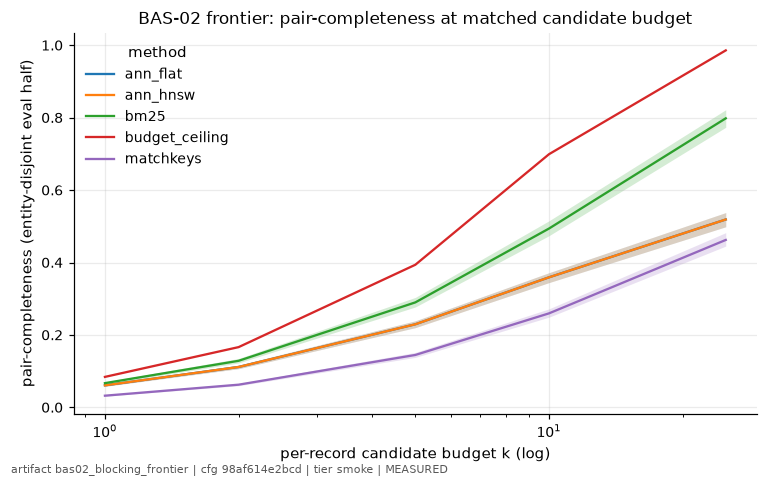

In [16]:
fig = figures.line_with_ci(
    registry, tier=cfg.run.tier, artifact="bas02_blocking_frontier",
    x="k", y="pc", lo="pc_lo", hi="pc_hi", hue="method", logx=True,
    title="BAS-02 frontier: pair-completeness at matched candidate budget",
    xlabel="per-record candidate budget k (log)",
    ylabel="pair-completeness (entity-disjoint eval half)",
    figsize=(7.0, 4.4),
)

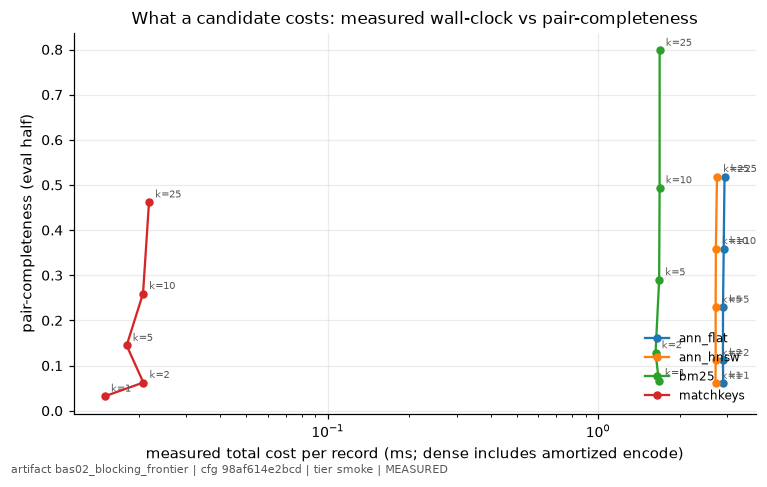

In [17]:
def draw_cost(ax, df, meta):
    d = df[~df["is_reference"]]
    for method, g in d.groupby("method"):
        g = g.sort_values("k")
        ax.plot(g["total_ms_per_rec"], g["pc"], "-o", label=str(method), markersize=4.5)
        for _, r in g.iterrows():
            ax.annotate(f"k={int(r['k'])}", (r["total_ms_per_rec"], r["pc"]),
                        textcoords="offset points", xytext=(4, 3), fontsize=6.5, color="0.35")
    ax.set_xscale("log")
    ax.set_xlabel("measured total cost per record (ms; dense includes amortized encode)")
    ax.set_ylabel("pair-completeness (eval half)")
    ax.legend(loc="lower right", fontsize=8)


fig = figures.plot_artifact(
    registry, tier=cfg.run.tier, artifact="bas02_blocking_frontier", draw=draw_cost,
    title="What a candidate costs: measured wall-clock vs pair-completeness",
    figsize=(7.0, 4.4),
)

## 6. The noise-regime slice: where would dense earn its place?

The claim dense blocking rides on is *robustness to corruption* — so slice PC at k=10 by
how corrupted each true pair actually is. The generator's ops log is the obvious
instrument, and the first cell below shows why it **inverts at this tier**: the records
carrying ≥ 3 logged ops are almost entirely notebook 05's household-confusable
*originals*, and their within-entity pairs are overwhelmingly byte-identical exact
duplicates (the ops are shared derivation, not differences *between* the pair). What
blocking experiences is the **disagreement between the two members**, so the slice dial
is the measured count of serialized roles on which the pair disagrees — corroborated
against the ops log on the pairs where the two instruments agree by construction
(1–2-op pairs are nearly always 1+-field-different).

In [18]:
t_sec = time.time()
_opc = ops_log.groupby(ops_log["record_id"].astype(str)).size()
_pair_ops = (EV_PAIRS["a"].map(_opc).fillna(0).to_numpy()
             + EV_PAIRS["b"].map(_opc).fillna(0).to_numpy())
_ev_vals = eval_full[TEXT_ROLES].astype("string").fillna("<NA>").to_numpy()
_pos = {rid: i for i, rid in enumerate(eval_full["record_id"].astype(str))}
_ia = EV_PAIRS["a"].map(_pos).to_numpy()
_ib = EV_PAIRS["b"].map(_pos).to_numpy()
DIFFS = (_ev_vals[_ia] != _ev_vals[_ib]).sum(axis=1)

_ops_heavy = _pair_ops >= 3
_ops_light = (_pair_ops >= 1) & (_pair_ops <= 2)
print("the ops-count instrument, measured on eval-half true pairs:")
print(f"  pairs with >= 3 summed ops: {int(_ops_heavy.sum()):,} — of which "
      f"{float((DIFFS[_ops_heavy] == 0).mean()):.0%} are IDENTICAL on all {len(TEXT_ROLES)} "
      "serialized roles (household-confusable originals x their exact-copy duplicates)")
print(f"  pairs with 1-2 summed ops:  {int(_ops_light.sum()):,} — of which "
      f"{float((DIFFS[_ops_light] >= 1).mean()):.0%} differ on >= 1 role (the instruments "
      "agree where they should)")
print("  -> at this tier 'ops >= 3' selects the EASIEST pairs, not the hardest; the slice "
      "dial below is the measured between-member field disagreement instead (deviation "
      "from the ops-count instrument, stated).")

SLICES = {
    "exact (0 roles differ)": DIFFS == 0,
    "light (1-2 differ)": (DIFFS >= 1) & (DIFFS <= 2),
    f"heavy (>= {HEAVY_MIN_DIFF} differ)": DIFFS >= HEAVY_MIN_DIFF,
}
print("\neval-half true pairs by measured corruption (of "
      f"{len(TEXT_ROLES)} roles; NA==NA counts as agreement):")
for _label, _sm in SLICES.items():
    print(f"  {_label:>22}: {int(_sm.sum()):>7,} pairs ({float(_sm.mean()):.0%})")

slice_rows: list[dict] = []
for _si, (_label, _sm) in enumerate(SLICES.items()):
    for _m in METHODS:
        fm = FOUND[(_m, SLICE_K)]
        pc, lo, hi = pc_ci(fm, subset=_sm)
        if _m == "bm25":
            d, dlo, dhi = np.nan, np.nan, np.nan
        else:
            d, dlo, dhi = paired_delta_ci(fm, FOUND[("bm25", SLICE_K)], subset=_sm)
        slice_rows.append({
            "method": _m, "slice": _label, "slice_order": _si, "k": SLICE_K,
            "pc": pc, "pc_lo": lo, "pc_hi": hi,
            "delta_vs_bm25": d, "delta_lo": dlo, "delta_hi": dhi,
            "n_true_pairs": int(_sm.sum()), "basis": "MEASURED",
        })
slice_df = pd.DataFrame(slice_rows)
registry.register(
    "bas02_noise_slice_pc", slice_df, cfg=cfg, tier=cfg.run.tier,
    meta={
        "design": f"per-method PC at k={SLICE_K} on eval-half true pairs sliced by measured "
                  f"between-member corruption: number of the {len(TEXT_ROLES)} serialized "
                  f"roles differing (exact=0 / light=1-2 / heavy>={HEAVY_MIN_DIFF})",
        "instrument_deviation": "the spec'd generator ops-count instrument (>= 3 logged ops) "
                                "inverts at this tier — those pairs are household-confusable "
                                "originals x exact-copy duplicates, byte-identical on every "
                                "serialized role (numbers printed in the notebook) — so the "
                                "dial is the measured field disagreement, ops-corroborated "
                                "on 1-2-op pairs",
        "deltas": "delta_vs_bm25 (+CI) is the paired entity-bootstrap PC delta vs the bm25 "
                  "arm on shared resamples",
        "single_seed_caveat": "dense rows depend on one trained encoder — demonstration",
        "corpus_provenance": CORPUS_PROVENANCE,
        "supports": "BAS-02 / bas02_blocking_frontier",
    },
)
print(f"\nregistered bas02_noise_slice_pc ({len(slice_df)} rows)")
_hv = slice_df[slice_df["slice_order"] == 2].set_index("method")
print(f"where dense earns its place, measured (heavy slice, k={SLICE_K}):")
for _m in ("ann_flat", "ann_hnsw", "matchkeys"):
    r = _hv.loc[_m]
    _sig = ("CI excludes 0" if (r["delta_lo"] > 0 or r["delta_hi"] < 0)
            else "CI includes 0")
    print(f"  {_m} - bm25 = {r['delta_vs_bm25']:+.4f} "
          f"[{r['delta_lo']:+.4f}, {r['delta_hi']:+.4f}] ({_sig})")
tick("§6 noise-regime slices", t_sec)

the ops-count instrument, measured on eval-half true pairs:
  pairs with >= 3 summed ops: 276 — of which 95% are IDENTICAL on all 6 serialized roles (household-confusable originals x their exact-copy duplicates)
  pairs with 1-2 summed ops:  3,897 — of which 100% differ on >= 1 role (the instruments agree where they should)
  -> at this tier 'ops >= 3' selects the EASIEST pairs, not the hardest; the slice dial below is the measured between-member field disagreement instead (deviation from the ops-count instrument, stated).

eval-half true pairs by measured corruption (of 6 roles; NA==NA counts as agreement):
  exact (0 roles differ):  34,989 pairs (19%)
      light (1-2 differ):  48,540 pairs (26%)
     heavy (>= 3 differ): 104,256 pairs (56%)

registered bas02_noise_slice_pc (12 rows)
where dense earns its place, measured (heavy slice, k=10):
  ann_flat - bm25 = -0.1533 [-0.1683, -0.1389] (CI excludes 0)
  ann_hnsw - bm25 = -0.1538 [-0.1687, -0.1397] (CI excludes 0)
  matchkeys - bm25

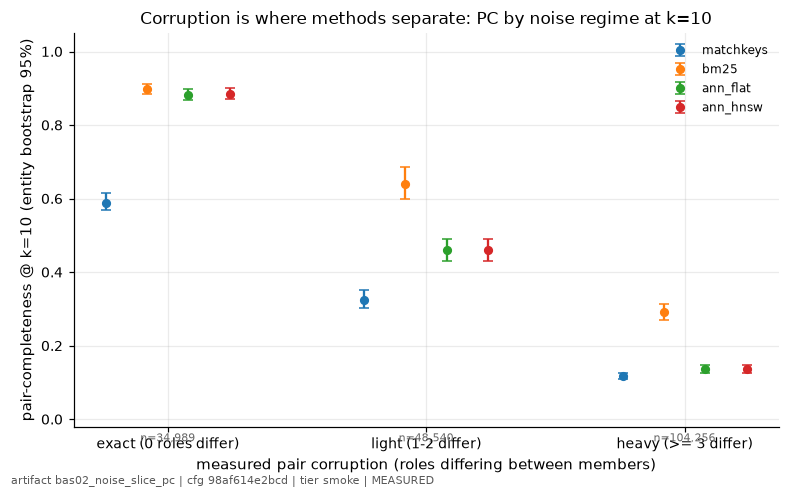

In [19]:
def draw_slices(ax, df, meta):
    order = df.sort_values("slice_order")["slice"].unique()
    xs = {s: i for i, s in enumerate(order)}
    offsets = {"matchkeys": -0.24, "bm25": -0.08, "ann_flat": 0.08, "ann_hnsw": 0.24}
    for method, off in offsets.items():
        g = df[df["method"] == method].sort_values("slice_order")
        x = g["slice"].map(xs).to_numpy(dtype=float) + off
        yerr = np.vstack([np.clip(g["pc"] - g["pc_lo"], 0, None),
                          np.clip(g["pc_hi"] - g["pc"], 0, None)])
        ax.errorbar(x, g["pc"], yerr=yerr, fmt="o", capsize=3, markersize=5, label=method)
    for s, i in xs.items():
        n = int(df[df["slice"] == s]["n_true_pairs"].iloc[0])
        ax.annotate(f"n={n:,}", (i, -0.06), ha="center", fontsize=7.5, color="0.4",
                    annotation_clip=False)
    ax.set_xticks(range(len(order)), [str(s) for s in order])
    ax.set_ylim(-0.02, 1.05)
    ax.set_xlabel("measured pair corruption (roles differing between members)")
    ax.set_ylabel(f"pair-completeness @ k={SLICE_K} (entity bootstrap 95%)")
    ax.legend(loc="best", fontsize=8)


fig = figures.plot_artifact(
    registry, tier=cfg.run.tier, artifact="bas02_noise_slice_pc", draw=draw_slices,
    title="Corruption is where methods separate: PC by noise regime at k=10",
    figsize=(7.2, 4.5),
)

## 7. Verdict — scored against the card, read as a demonstration

In [20]:
_pcf = frontier[~frontier["is_reference"]].set_index(["method", "k"])["pc"]
DELTAS = {k: paired_delta_ci(FOUND[("bm25", k)], FOUND[("ann_flat", k)]) for k in K_GRID}
print("paired deltas (bm25 − ann_flat), shared entity resamples:")
for _k in K_GRID:
    d, lo, hi = DELTAS[_k]
    print(f"  k={_k:>2}: {d:+.4f} [{lo:+.4f}, {hi:+.4f}]")
P1_KS = (1, 2, 5, 10)
p1_holds = all(DELTAS[k][0] >= 0 for k in P1_KS)
p2_gap = float(_pcf[("bm25", 25)] - _pcf[("ann_flat", 25)])
p2_holds = _pcf[("ann_flat", 25)] >= _pcf[("bm25", 25)] - 0.05
p3_gap = float(_pcf[("ann_flat", SLICE_K)] - _pcf[("ann_hnsw", SLICE_K)])
p3_holds = p3_gap <= 0.02
refute_p1 = any(DELTAS[k][0] < 0 and DELTAS[k][2] < 0 for k in P1_KS)
refute_p2 = (not p2_holds) and DELTAS[25][1] > 0.05
if refute_p1 or refute_p2:
    bas02_outcome = "REFUTED"
elif p1_holds and p2_holds:
    bas02_outcome = "CONFIRMED"
else:
    bas02_outcome = "UNEXPLAINED"
_hv_flat = _hv.loc["ann_flat"]
print(f"\nP1 (bm25 >= dense-flat at k in {P1_KS}): {p1_holds} "
      f"(significant dense win anywhere: {refute_p1})")
print(f"P2 (dense within 0.05 at k=25): {p2_holds} (gap {p2_gap:+.4f}; "
      f"significantly beyond the margin: {refute_p2})")
print(f"P3 (hnsw within 0.02 of flat at k={SLICE_K}): {p3_holds} (flat−hnsw = {p3_gap:+.4f})")
print(f"heavy-slice reading: ann_flat − bm25 = {_hv_flat['delta_vs_bm25']:+.4f} "
      f"[{_hv_flat['delta_lo']:+.4f}, {_hv_flat['delta_hi']:+.4f}]")
print(f"-> outcome: {bas02_outcome}")

_ = verdict_box(
    "BAS-02",
    outcome=bas02_outcome,
    evidence=(
        f"bas02_blocking_frontier + bas02_noise_slice_pc (tier {TIER}, {N_ARENA:,}-record "
        f"arena, eval-half scoring on {len(EV_PAIRS):,} entity-disjoint true pairs, "
        f"{N_BOOT} paired entity resamples). P1 bm25−flat deltas at k {list(P1_KS)}: "
        + ", ".join(f"{DELTAS[k][0]:+.4f}" for k in P1_KS)
        + f" -> holds: {p1_holds} (a significant dense win would refute: {refute_p1}). "
        f"P2 at k=25: gap {p2_gap:+.4f} vs the 0.05 margin -> holds: {p2_holds} "
        f"(CI beyond the margin: {refute_p2}). P3 flat−hnsw at k={SLICE_K}: {p3_gap:+.4f} "
        f"vs 0.02 -> holds: {p3_holds}. Corruption slice at k={SLICE_K}: ann_flat−bm25 = "
        f"{_hv_flat['delta_vs_bm25']:+.4f} [{_hv_flat['delta_lo']:+.4f}, "
        f"{_hv_flat['delta_hi']:+.4f}] on heavy pairs (>= {HEAVY_MIN_DIFF} roles differ; "
        "the spec'd ops-count instrument inverts at this tier — measured in §6 — so the "
        "dial is field disagreement). DEMONSTRATION, not adjudication: the dense arms ride "
        f"ONE trained encoder (seed {PRIMARY_SEED}, one corpus draw) — the MET-04 "
        f"residual-inclusive replicate bar is {BAR_FULL:.4f} B³F1 ({_bar_src}), an "
        "order-of-magnitude warning that single-encoder margins of similar size are "
        "run-to-run noise; and smoke-tier index size (~3e4) is 300x below the 1e7 the "
        "question names. The target-tier frontier (placard below) is the adjudication."
    ),
    registry=registry,
)

paired deltas (bm25 − ann_flat), shared entity resamples:
  k= 1: +0.0061 [+0.0055, +0.0068]
  k= 2: +0.0171 [+0.0155, +0.0188]
  k= 5: +0.0605 [+0.0553, +0.0661]
  k=10: +0.1347 [+0.1241, +0.1461]
  k=25: +0.2793 [+0.2611, +0.2972]

P1 (bm25 >= dense-flat at k in (1, 2, 5, 10)): True (significant dense win anywhere: False)
P2 (dense within 0.05 at k=25): False (gap +0.2793; significantly beyond the margin: True)
P3 (hnsw within 0.02 of flat at k=10): True (flat−hnsw = +0.0000)
heavy-slice reading: ann_flat − bm25 = -0.1533 [-0.1683, -0.1389]
-> outcome: REFUTED


> ### VERDICT: REFUTED — card `BAS-02`
>
> **Conjecture** On noisy person records at a matched per-record candidate budget, dense ANN retrieval over trained whole-record embeddings does not beat well-tuned sparse BM25 blocking at small budgets — the lit review marks dense-beats-sparse as CONTESTED (Sparkly / ShallowBlocker / Zeakis et al.), and this card pre-registers the sparse-favored reading — with dense closing as the budget grows and earning whatever place it has on heavily-corrupted matches where token overlap and phonetic keys break.
>
> **Prediction** P1: BM25 pair-completeness >= dense-flat at every k in {1, 2, 5, 10} (point estimates, eval half). P2: dense-flat closes to within 0.05 absolute PC of BM25 at k=25. P3 (subordinate): HNSW gives up <= 0.02 PC vs flat at k=10 — at this scale the index, not the embedding, is not the bottleneck. Decision rule, pre-registered: CONFIRMED iff P1 and P2 both hold; REFUTED iff dense-flat beats BM25 at some k <= 10 with the paired entity-bootstrap 95% CI on the delta excluding zero, or P2 fails with the k=25 delta CI entirely beyond the 0.05 margin; UNEXPLAINED otherwise. P3 and the corruption-slice reading (dense ahead, if anywhere, on pairs disagreeing on >= 3 roles) are scored as stated but cannot flip the outcome. One trained encoder, one corpus draw: whatever the outcome, the smoke row is a demonstration and the target-tier frontier is the adjudication.
>
> **Evidence** bas02_blocking_frontier + bas02_noise_slice_pc (tier smoke, 32,259-record arena, eval-half scoring on 187,785 entity-disjoint true pairs, 400 paired entity resamples). P1 bm25−flat deltas at k [1, 2, 5, 10]: +0.0061, +0.0171, +0.0605, +0.1347 -> holds: True (a significant dense win would refute: False). P2 at k=25: gap +0.2793 vs the 0.05 margin -> holds: False (CI beyond the margin: True). P3 flat−hnsw at k=10: +0.0000 vs 0.02 -> holds: True. Corruption slice at k=10: ann_flat−bm25 = -0.1533 [-0.1683, -0.1389] on heavy pairs (>= 3 roles differ; the spec'd ops-count instrument inverts at this tier — measured in §6 — so the dial is field disagreement). DEMONSTRATION, not adjudication: the dense arms ride ONE trained encoder (seed 17, one corpus draw) — the MET-04 residual-inclusive replicate bar is 0.0865 B³F1 (read from met04_power_table meta), an order-of-magnitude warning that single-encoder margins of similar size are run-to-run noise; and smoke-tier index size (~3e4) is 300x below the 1e7 the question names. The target-tier frontier (placard below) is the adjudication.


## 8. Pricing the real thing: the 1e7 frontier

In [21]:
# [RUN-IN-TARGET node] the definitive BAS-02 frontier: THESE same cells at tier=target on
# the node — 1e7-record calibrated corpus, multi-seed encoders (replicates per
# met04_power_table at that tier), same k grid, same registry names. The estimates below
# use THIS run's measured coefficients (4-CPU container, single-thread faiss; a concurrent
# workload can inflate them 2-4x — they are planning numbers, re-measured on arrival).
if TIER == "target":
    print("tier=target: the frontier above IS the definitive BAS-02 frontier at this scale; "
          "replicate counts come from met04_power_table at this tier.")
else:
    N7 = 1e7
    _row = frontier[~frontier["is_reference"]].set_index(["method", "k"])
    _bm25_s = float(_row.loc[("bm25", SLICE_K), "block_secs"])
    _hnsw_s = float(_row.loc[("ann_hnsw", SLICE_K), "block_secs"])
    _flat_s = float(_row.loc[("ann_flat", SLICE_K), "block_secs"])
    _mk_s = float(_row.loc[("matchkeys", SLICE_K), "block_secs"])
    enc_h = N7 / ENC_RATE / 3600
    mk_h = _mk_s / N_ARENA * N7 / 3600
    bm25_h = _bm25_s / N_ARENA * N7 / 3600  # naive linear scaling of index+search
    hnsw_c = _hnsw_s / (N_ARENA * np.log2(N_ARENA))
    hnsw_h = hnsw_c * N7 * np.log2(N7) / 3600  # ~n log n build+search, single thread
    flat_c = _flat_s / (N_ARENA**2)
    flat_d = flat_c * N7**2 / 86400  # exact search is O(n^2): the ceiling, not a method
    mem_gb = N7 * EMB.shape[1] * 4 / 2**30
    mem_gb_t = N7 * 384 * 4 / 2**30
    print(f"[RUN-IN-TARGET node] 1e7 frontier priced from THIS run's coefficients "
          f"(n={N_ARENA:,}, k={SLICE_K}):")
    print(f"  encode: measured {ENC_RATE:,.0f} rec/s -> {enc_h:.1f} h for 1e7 on this "
          f"container; PLAN §8 books ~20k rec/s/GPU -> ~{N7 / 20_000 / 60:.0f} min on one "
          "A100 (planning number, ±2x)")
    print(f"  matchkeys: {_mk_s / N_ARENA * 1e3:.2f} ms/rec -> ~{mk_h:.1f} h at 1e7 "
          "(linear; passes are hash-group-and-window)")
    print(f"  bm25: {_bm25_s / N_ARENA * 1e3:.2f} ms/rec incl. re-index -> ~{bm25_h:.0f} h "
          "at 1e7 naive-linear on one core; Sparkly demonstrates Lucene BM25 blocking at "
          "1e8+ tuples (lit review), so treat this as an upper bound")
    print(f"  ann_hnsw: {_hnsw_s / N_ARENA * 1e3:.2f} ms/rec -> ~{hnsw_h:.0f} h at 1e7 "
          "under ~n·log2(n) scaling, single faiss thread (the module's determinism rail); "
          "the node has 90 cores + 4 A100s to shard encode/search across")
    print(f"  ann_flat: O(n²) exact search -> ~{flat_d:,.0f} DAYS at 1e7 single-thread — "
          "flat is the recall ceiling instrument, never the deployable arm; HNSW-vs-flat "
          "recall is what P3 tracks")
    print(f"  memory: 1e7 x {EMB.shape[1]}-d fp32 = {mem_gb:.1f} GB "
          f"(target-tier 384-d: {mem_gb_t:.1f} GB) — inside the mac's 96 GB, trivially "
          "inside the node's 900 GB (PLAN §8); candidate table at k=25 ~ 2.5e8 pairs")

[RUN-IN-TARGET node] 1e7 frontier priced from THIS run's coefficients (n=32,259, k=10):
  encode: measured 385 rec/s -> 7.2 h for 1e7 on this container; PLAN §8 books ~20k rec/s/GPU -> ~8 min on one A100 (planning number, ±2x)
  matchkeys: 0.02 ms/rec -> ~0.1 h at 1e7 (linear; passes are hash-group-and-window)
  bm25: 1.69 ms/rec incl. re-index -> ~5 h at 1e7 naive-linear on one core; Sparkly demonstrates Lucene BM25 blocking at 1e8+ tuples (lit review), so treat this as an upper bound
  ann_hnsw: 0.12 ms/rec -> ~1 h at 1e7 under ~n·log2(n) scaling, single faiss thread (the module's determinism rail); the node has 90 cores + 4 A100s to shard encode/search across
  ann_flat: O(n²) exact search -> ~11 DAYS at 1e7 single-thread — flat is the recall ceiling instrument, never the deployable arm; HNSW-vs-flat recall is what P3 tracks
  memory: 1e7 x 128-d fp32 = 4.8 GB (target-tier 384-d: 14.3 GB) — inside the mac's 96 GB, trivially inside the node's 900 GB (PLAN §8); candidate table at k=25

## 9. What the rest of the series inherits

- **`bas02_blocking_frontier` is now the lab's blocking evidence.** Notebook 13 consumes
  it by DAG contract (its pair scoring starts from a blocked candidate set); notebook 15
  builds the scaling ladder and the 1e9 cost model on the same measured per-record
  coefficients this notebook registered (encode rate, per-method ms/record).
- **The contested claim stays contested until the node runs.** The lit review's framing
  — dense-beats-sparse unproven against well-tuned lexical baselines, dense degrading
  with index size, and *no person-record evidence either way* — is exactly what the
  pre-registered card tested at smoke scale, and the verdict above says which way this
  one corpus, one encoder, one draw landed **and why that is not yet an adjudication**.
  The `# [RUN-IN-TARGET node]` frontier at 1e7 with met04-sized replicates is the
  experiment the literature is missing; whichever way it lands, the matched-budget,
  matched-cost, entity-disjoint protocol here is the lab's actual contribution.
- **The budget ceiling and the noise slices are reusable instruments.** HYB-01's
  rules-vs-embeddings regime map (notebook 14) reads directly off the corruption-sliced
  PC; the ceiling rows keep every downstream recall claim honest about what k allows.

**Artifacts registered** (exact names): `bas02_blocking_frontier` — plus supporting
`bas02_noise_slice_pc` and the immutable card `card_BAS-02`.

In [22]:
timing = pd.DataFrame(SECTION_TIMES, columns=["section", "secs"])
display(timing.assign(secs=timing["secs"].round(0)))
total = time.time() - NB_T0
print(f"notebook wall-clock: {total:.0f}s ({total / 60:.1f} min) — smoke budget <= ~30 min"
      + ("" if total <= 2100 else "  <-- OVER BUDGET at this run; see section table"))

,section,secs
0,§1 arena + instruments,1.0
1,§3 recipe + train + encode,600.0
2,§4a matchkeys arm,5.0
3,§4b bm25 arm,272.0
4,§4c ann_flat arm,52.0
5,§4d ann_hnsw arm,23.0
6,§4e ceiling + register + leakage check,0.0
7,§6 noise-regime slices,0.0


notebook wall-clock: 954s (15.9 min) — smoke budget <= ~30 min
